# Wildfire Prediction with PyTorch

The aim of this project is to use PyTorch to apply a pre-trained model for classifying satellite images of areas with or without wildfire.

The overall flow of the programme is based on the OpenCV University course PyTorch Bootcamp Deep-Learning module on transfer learning, and the PyTorch tutorial on transfer learning. More specific references can be found in their respective sections below.

**References:**   
https://courses.opencv.org/courses/course-v1:PyTorch+Bootcamp+Deep-Learning/course/ - Module 6: Transfer Learning & Fine-Tuning  
https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html 

In [ ]:
# Libraries
import kagglehub
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import time

from pathlib import Path
from PIL import Image

from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# torch.manual_seed(42)

## Download and Extract the Wildfire Prediction Dataset from Kaggle

The project uses "Wildfire Prediction Dataset (Satellite Images)" from Kaggel (abdelghaniaaba). The dataset contains 42 850 satellite images of size 350x350 pixels RGB divided into two classes 22 710 assigned wildfire and 20 140 assigned nowildfire. 

The images are obtained from documented wildfires of more than 0.01 acres from the Canadian Government open dataportal.

The dataset is divided into 70% training, 15% validation and 15% test.

**References:**  
https://www.kaggle.com/datasets/abdelghaniaaba/wildfire-prediction-dataset/data  
https://www.kaggle.com/docs/api  
https://github.com/Kaggle/kagglehub  

In [37]:
# Get dataset from Kaggle

path = kagglehub.dataset_download("abdelghaniaaba/wildfire-prediction-dataset")
print(path)

C:\Users\malin\.cache\kagglehub\datasets\abdelghaniaaba\wildfire-prediction-dataset\versions\1


In [38]:
# Copy dataset to project data folder

dest = Path("data/wildfire_dataset")
if not dest.exists():
    shutil.copytree(path, dest)
    print(f"Copied to {dest.resolve()}")
else:
    print(f"{dest} already exists, no need to copy")

data\wildfire_dataset already exists, no need to copy


## Exploratory Data Analysis

The EDA checks the dataset size, the shape of the images and if any files are broken, and looks at examples of images.

Two broken files were found and removed, and the dataset size was rechecked afterwards.

**References:**  
https://pillow.readthedocs.io/en/stable/reference/Image.html 

In [39]:
# Look at dataset size

rows = []
for split in ["train", "valid", "test"]:
    for cls in ["wildfire", "nowildfire"]:
        folder = Path(f"data/wildfire_dataset/{split}/{cls}")
        for file in folder.iterdir():
            rows.append({"split": split, "class": cls})

df = pd.DataFrame(rows)
df.value_counts(["split", "class"])

split  class     
train  wildfire      15750
       nowildfire    14499
valid  wildfire       3480
test   wildfire       3479
valid  nowildfire     2820
test   nowildfire     2820
Name: count, dtype: int64

In [40]:
# Check image shape for all images

shapes = set()

# Save potentially broken files
broken_files = []

# Loop through images
for split in ["train", "valid", "test"]:
    for cls in ["wildfire", "nowildfire"]:
        folder = Path(f"data/wildfire_dataset/{split}/{cls}")
        for file in folder.iterdir():
            try:
                with Image.open(file) as img:
                    shapes.add(np.array(img).shape)
            except OSError as e:
                broken_files.append((file, str(e)))

print(shapes)
print(f"\nFound {len(broken_files)} broken files:")
for file, error in broken_files:
    print(file, "_", error)

{(350, 350, 3)}

Found 0 broken files:


In [41]:
# Remove potentially broken files
for file, _ in broken_files:
    file.unlink()
    print(f"Removed {file}")

In [42]:
# Check dataset size after removing potentially broken files
rows = []
for split in ["train", "valid", "test"]:
    for cls in ["wildfire", "nowildfire"]:
        folder = Path(f"data/wildfire_dataset/{split}/{cls}")
        for file in folder.iterdir():
            rows.append({"split": split, "class": cls})

df = pd.DataFrame(rows)
df.value_counts(["split", "class"])

split  class     
train  wildfire      15750
       nowildfire    14499
valid  wildfire       3480
test   wildfire       3479
valid  nowildfire     2820
test   nowildfire     2820
Name: count, dtype: int64

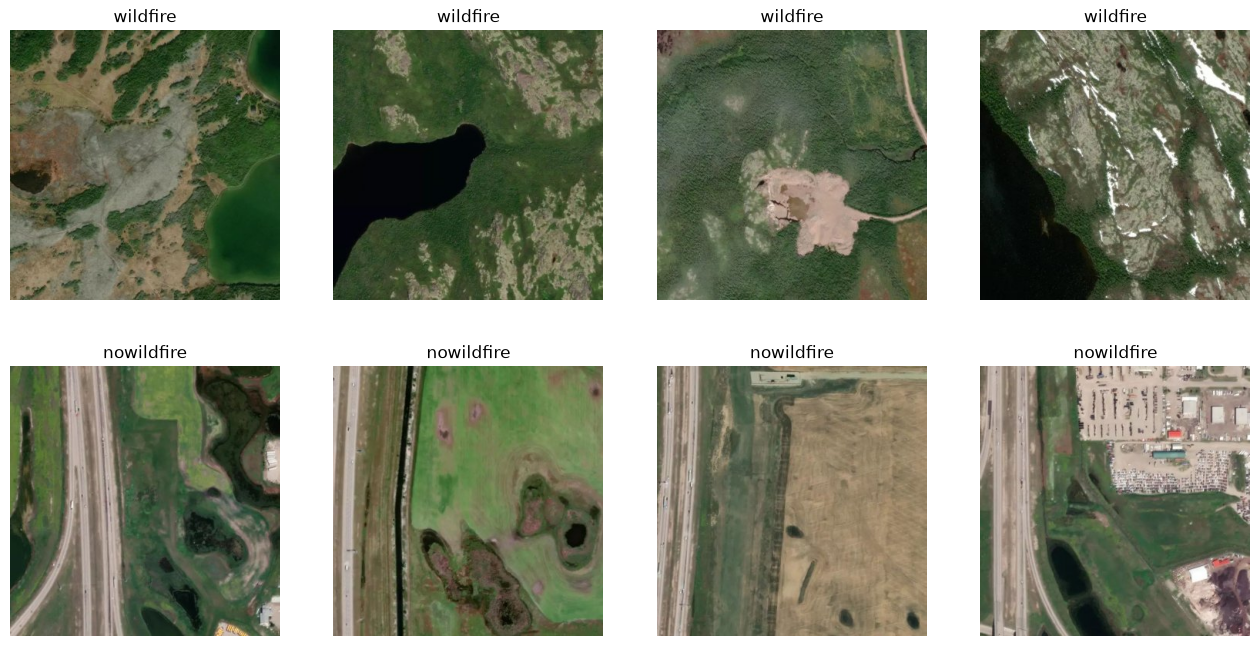

In [43]:
# Look at example images

n_images = 4

fig, axes = plt.subplots(2, n_images, figsize=(4 * n_images, 8))

for row, cls in zip(axes, ["wildfire", "nowildfire"]):
    folder = Path("data/wildfire_dataset/train") / cls
    files = list(folder.iterdir())[:n_images]
    for ax, file in zip(row, files):
        img = Image.open(file)
        ax.imshow(img)
        ax.set_title(cls)
        ax.axis("off")

plt.show()

## Preprocess the Input Images Using Transforms

The preprocessing applied to the dataset makes the images compatible with the pre-trained model's expected input format and converts them into PyTorch tensors.  

For the training dataset augmentation is also used.

**References:**  
https://docs.pytorch.org/vision/stable/transforms.html#transform-classes-functionals-and-kernels

In [ ]:
# Preprocessing to be applied to train, valid and test.
image_transform = {
    "train": transforms.Compose([
                  transforms.Resize((224, 224)),            # Resize the image to 224×224 pixels.
                  transforms.RandomHorizontalFlip(p=0.5),   # Augmentation flipping the image
                  transforms.RandomRotation(degrees=15),    # Augmentation rotating the image
                  transforms.ToTensor(),                    # Convert the image to PyTorch Tensor data type.
                  transforms.Normalize(
                  mean=[0.485, 0.456, 0.406],               # Normalize the image with ImageNet mean and std.
                  std=[0.229, 0.224, 0.225])
    ]),
    "valid": transforms.Compose([
                  transforms.Resize((224, 224)),
                  transforms.ToTensor(),
                  transforms.Normalize(
                  mean=[0.485, 0.456, 0.406],
                  std=[0.229, 0.224, 0.225])
    ]),
    "test": transforms.Compose([
                  transforms.Resize((224, 224)),
                  transforms.ToTensor(),
                  transforms.Normalize(
                  mean=[0.485, 0.456, 0.406],
                  std=[0.229, 0.224, 0.225])
    ])
}

## Dataset Preparation

The data is loaded and transformed, indices are mapped to class names, and dataset size and image shape are checked after.

The training dataset is also shuffled.

**References:**  
https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

In [47]:
# Loading data

# Setting directory paths
data_root = Path("data/wildfire_dataset")
train_directory = data_root / "train"
valid_directory = data_root / "valid"
test_directory = data_root / "test"

# Batch size
batch_size = 32

# Number of classes
num_classes = len(list(valid_directory.iterdir()))
print(f"Number of classes: {num_classes}")

# Load data from folders
data = {
    "train": datasets.ImageFolder(root=train_directory, transform = image_transform["train"]),
    "valid": datasets.ImageFolder(root=valid_directory, transform = image_transform["valid"]),
    "test": datasets.ImageFolder(root=test_directory, transform = image_transform["test"]),
}

# Get mapping of indices to class names
idx_to_class = {v: k for k, v in data["train"].class_to_idx.items()}
print(f"Index and class name: {idx_to_class}")

# Size of datasets
train_data_size = len(data["train"])
valid_data_size = len(data["valid"])
test_data_size = len(data["test"])
print (f"Training dataset size: {train_data_size}")
print (f"Validation dataset size: {valid_data_size}")
print (f"Test dataset size: {test_data_size}")

# Iterators for loading data
train_data_loader = DataLoader(data["train"], batch_size=batch_size, shuffle=True)
valid_data_loader = DataLoader(data["valid"], batch_size=batch_size, shuffle=False)
test_data_loader = DataLoader(data["test"], batch_size=batch_size, shuffle=False)

Number of classes: 2
Index and class name: {0: 'nowildfire', 1: 'wildfire'}
Training dataset size: 30249
Validation dataset size: 6300
Test dataset size: 6299


In [48]:
# Check the shape after preprocessing
images, labels = next(iter(train_data_loader))
print(f"Image shape: {images.shape}")
print(f"Image type: {images.dtype}")
print(f"Check of labels in one batch: {labels.shape, labels}")

Image shape: torch.Size([32, 3, 224, 224])
Image type: torch.float32
Check of labels in one batch: (torch.Size([32]), tensor([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 1, 0, 0, 0, 0, 1]))


## Import the ResNet18 Pre-Trained Model

The pre-trained model chosen is ResNet18. When the model has been loaded the model architecture is checked.

In [49]:
# Set the choice of device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [50]:
# Import pre-trained ResNet18 Model
resnet18 = models.resnet18(weights='DEFAULT')
resnet18 = resnet18.to(device)

In [51]:
# Check the model architecture
print(resnet18)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Configure the Model for Transfer Learning

The pre-trained model's feature extractor will be used as it is and only the fully connected layer classifier will be trained on the new data.

**References:**  
https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html#convnet-as-fixed-feature-extractor

In [52]:
# Freeze model parameters
for param in resnet18.parameters():
    param.requires_grad = False

In [53]:
# Unfreeze and configure classification layer

# Change the final fully connected layer of the ResNet18 model for transfer learning
fc_inputs = resnet18.fc.in_features  # Get the number of input features for the final layer

# Define a new fully connected layer with custom architecture for classification
resnet18.fc = nn.Sequential(
    nn.Linear(fc_inputs, 256),  # Fully connected layer with 256 neurons
    nn.ReLU(),  # Apply ReLU activation
    nn.Dropout(0.4),  # Apply dropout with 40% probability to prevent overfitting
    nn.Linear(256, num_classes),  # Output layer with number of classes as output neurons
)

# Move the model to the appropriate device (either CUDA or CPU)
resnet18 = resnet18.to(device)

## Training Configuration

For training configuration, CrossEntropyLoss and the Adam optimizer are chosen. A learning rate of 0.001 was chosen to match typical values for the Adam optimizer.

In [54]:
# Define the loss function for classification
loss_func = nn.CrossEntropyLoss()

# Define the optimizer and learning rate
optimizer = torch.optim.Adam(
    (p for p in resnet18.parameters() if p.requires_grad),
    lr=0.001
)

## Model Training Function

The function loops through the training and the validation images, calculating loss and accuracy. For the training dataset backpropagation for updating weights is used. The best-performing model (lowest validation loss) is saved as best_model.pt.

**References:**  
https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html  
https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html

In [55]:
def model_compile_and_fit(model, loss_func, optimizer, epochs=10):
    """Function to train and validate"""

    start_time = time.time()
    history = []
    best_loss = 100000.0
    best_epoch = None

    for epoch in range(epochs):
        epoch_start = time.time()
        print("Epoch: {}/{}".format(epoch, epochs))

        # Set to training mode only for last layer
        model.eval()
        model.fc.train()

        # Loss and Accuracy within the epoch
        train_loss = 0.0
        train_acc = 0.0

        valid_loss = 0.0
        valid_acc = 0.0

        for i, (inputs, labels) in enumerate(train_data_loader):
            # Sending images and labels to device
            inputs = inputs.to(device) 
            labels = labels.to(device)
            optimizer.zero_grad()                                               # Clean existing gradients
            outputs = model(inputs)                                             # Forward pass - compute outputs on input data using the model
            loss = loss_func(outputs, labels)                                   # Calculate loss
            loss.backward()                                                     # Backpropagate the gradients
            optimizer.step()                                                    # Update the parameters
            train_loss += loss.item() * inputs.size(0)                          # Calculate the total loss for the batch and add it to train_loss
            ret, predictions = torch.max(outputs.data, 1)                       # Calculate the accuracy
            correct_counts = predictions.eq(labels.data.view_as(predictions))   # Check which predictions were correct
            acc = torch.mean(correct_counts.type(torch.FloatTensor))            # Convert correct_counts to float and then compute the mean
            train_acc += acc.item() * inputs.size(0)                            # Calculate total accuracy in the whole batch and add to train_acc

        # Validation - No gradient tracking needed
        with torch.no_grad():
            model.eval()

            for j, (inputs, labels) in enumerate(valid_data_loader):
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
                loss = loss_func(outputs, labels)
                valid_loss += loss.item() * inputs.size(0)
                ret, predictions = torch.max(outputs.data, 1)
                correct_counts = predictions.eq(labels.data.view_as(predictions))
                acc = torch.mean(correct_counts.type(torch.FloatTensor))
                valid_acc += acc.item() * inputs.size(0)

            if valid_loss < best_loss:
                best_loss = valid_loss
                best_epoch = epoch

                # Save if the model has the lowest validation loss so far
                torch.save({
                    "model_state_dict": model.state_dict(),
                    "idx_to_class": idx_to_class,
                }, "best_model.pt")

        # Find average training loss and training accuracy
        avg_train_loss = train_loss/train_data_size
        avg_train_acc = train_acc/train_data_size

        # Find average validation loss and validation accuracy
        avg_valid_loss = valid_loss/valid_data_size
        avg_valid_acc = valid_acc/valid_data_size

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        epoch_end = time.time()

        print("Epoch : {:03d}, Training: Loss - {:.4f}, Accuracy - {:.4f}%, \n\t\tValidation : Loss - {:.4f}, Accuracy - {:.4f}%, Time: {:.4f}s".format(epoch, avg_train_loss, avg_train_acc*100, avg_valid_loss, avg_valid_acc*100, epoch_end-epoch_start))

    print(f"Total time: {(time.time() - start_time)/60:.1f} min")

    return model, history, best_epoch


## Run Training

In [ ]:
model, history, best_epoch = model_compile_and_fit(resnet18, loss_func, optimizer, epochs=10)
history = np.array(history)

Epoch: 0/10
Epoch : 000, Training: Loss - 0.1754, Accuracy - 93.2361%, 
		Validation : Loss - 0.1356, Accuracy - 94.6190%, Time: 1033.6077s
Epoch: 1/10
Epoch : 001, Training: Loss - 0.1454, Accuracy - 94.3668%, 
		Validation : Loss - 0.1234, Accuracy - 95.0952%, Time: 1006.7028s
Epoch: 2/10
Epoch : 002, Training: Loss - 0.1344, Accuracy - 94.8263%, 
		Validation : Loss - 0.1390, Accuracy - 94.5397%, Time: 1004.4716s
Epoch: 3/10
Epoch : 003, Training: Loss - 0.1304, Accuracy - 95.1635%, 
		Validation : Loss - 0.1090, Accuracy - 96.0000%, Time: 999.1868s
Epoch: 4/10
Epoch : 004, Training: Loss - 0.1250, Accuracy - 95.3189%, 
		Validation : Loss - 0.1087, Accuracy - 95.8571%, Time: 957.1166s
Epoch: 5/10
Epoch : 005, Training: Loss - 0.1209, Accuracy - 95.4478%, 
		Validation : Loss - 0.1066, Accuracy - 95.9524%, Time: 939.0568s
Epoch: 6/10
Epoch : 006, Training: Loss - 0.1174, Accuracy - 95.5701%, 
		Validation : Loss - 0.1044, Accuracy - 96.0952%, Time: 926.4542s
Epoch: 7/10
Epoch : 007,

## Plot the Training Logs

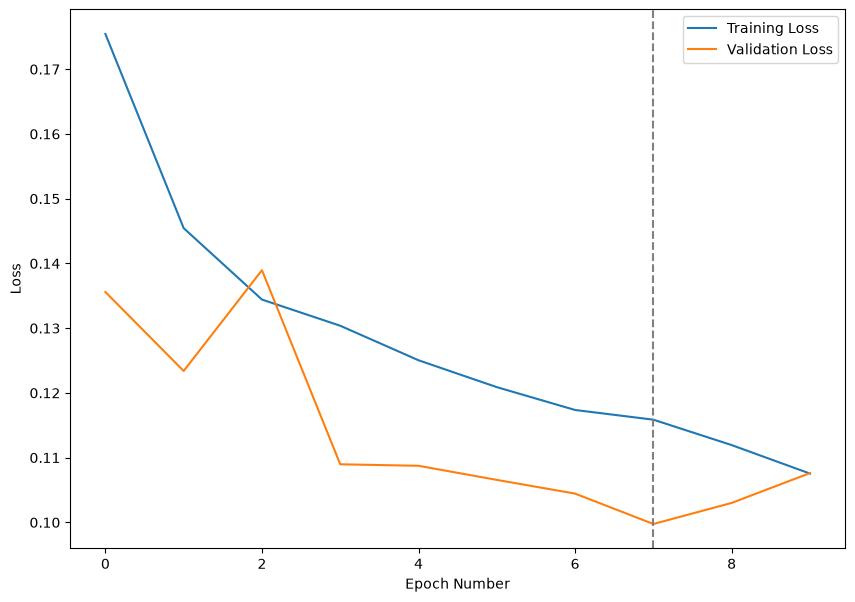

In [56]:
plt.figure(figsize=(10, 7))
plt.plot(history[:,0:2])
plt.legend(["Training Loss", "Validation Loss"])
plt.xlabel("Epoch Number")
plt.ylabel("Loss")
plt.axvline(best_epoch, linestyle="--", color="gray")
plt.savefig("loss_curve.png")
plt.show()

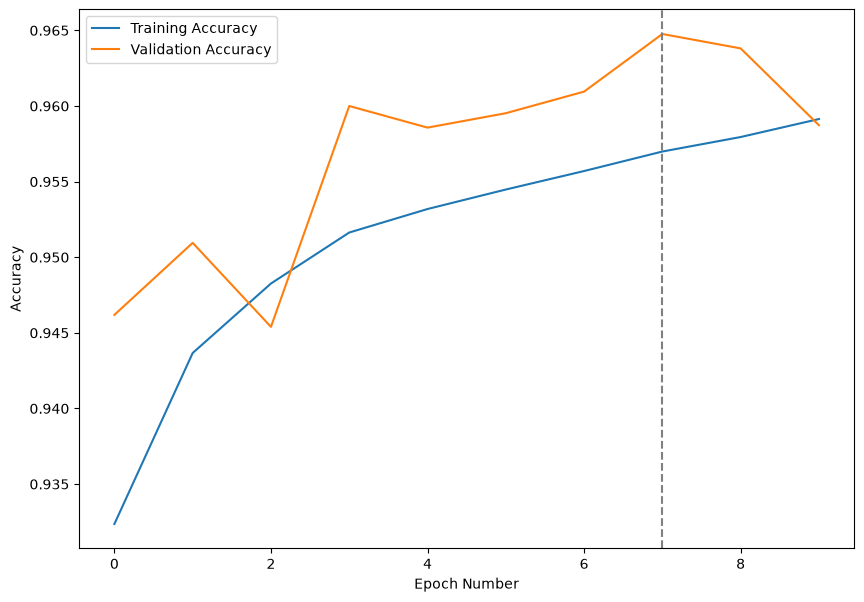

In [57]:
plt.figure(figsize=(10, 7))
plt.plot(history[:,2:4])
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.xlabel("Epoch Number")
plt.ylabel("Accuracy")
plt.axvline(best_epoch, linestyle="--", color="gray")
plt.savefig("accuracy_curve.png")
plt.show()

### Comment on Plots

The model reaches a low loss and high accuracy quickly. The curves follow each other well. In both graphs,overfitting is seen sometime after 8 epochs as training loss keeps decreasing while validation loss increases. 

The best epoch is the 8th (as first epoch is 0).

## Inference

The best model is evaluated on the test dataset.

**References:**  
(https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-a-general-checkpoint-for-inference-and-or-resuming-training)

In [58]:
# Load checkpoint from file
checkpoint = torch.load(
    "best_model.pt",
    map_location=device,
    weights_only=True
)

# Recreate model architecture
best_model = models.resnet18(weights=None)

# Get the number of input features for the final fully connected layer
fc_inputs = best_model.fc.in_features

# Recreate the new fully connected layer with custom architecture for classification
best_model.fc = nn.Sequential(
    nn.Linear(fc_inputs, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

# Load the trained weights into the recreated model
best_model.load_state_dict(checkpoint["model_state_dict"])

# Translate class index to class names
idx_to_class = checkpoint["idx_to_class"]

# Move the model to the appropriate device (either CUDA or CPU)
best_model = best_model.to(device)

In [59]:
def best_model_inference(model, loss_func):
    """Function to compute accuracy and loss of the best model on test data"""

    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    with torch.no_grad():

        for j, (inputs, labels) in enumerate(test_data_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = loss_func(outputs, labels)
            test_loss += loss.item() * inputs.size(0)
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))
            acc = torch.mean(correct_counts.type(torch.FloatTensor))
            test_acc += acc.item() * inputs.size(0)

    avg_test_loss = test_loss/test_data_size
    avg_test_acc = test_acc/test_data_size
   
    print("Test : Loss - {:.4f}, Accuracy - {:.4f}%".format(avg_test_loss, avg_test_acc*100))

    test_results = {"loss": avg_test_loss, "accuracy": avg_test_acc}
    return test_results


In [60]:
# Run test
test_results = best_model_inference(best_model, loss_func)

valid_loss_best = history[best_epoch, 1]
valid_acc_best = history[best_epoch, 3]

print("Validation best epoch: Loss - {:.4f}, Accuracy - {:.4f}%".format(valid_loss_best, valid_acc_best*100))

Test : Loss - 0.0787, Accuracy - 97.2218%
Validation best epoch: Loss - 0.0997, Accuracy - 96.4762%


## Confusion Matrix on Test Data

In [61]:
def predict_classes(model, test_data_loader):
    """Function for predictions"""

    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_data_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            ret, predictions = torch.max(outputs.data, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())

    return all_labels, all_preds

In [ ]:
# Get predictions
y_true, y_pred = predict_classes(best_model, test_data_loader)

In [62]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion matrix"):
    """Function to plot confusion matrix"""

    labels = np.arange(len(class_names))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    display.plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return cm

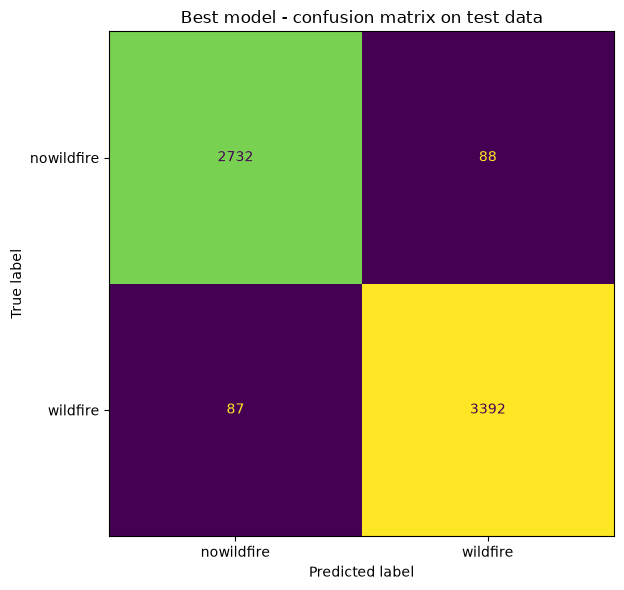

In [63]:
# Plot confusion matrix
class_names = [idx_to_class[i] for i in sorted(idx_to_class)]

best_model_cm = plot_confusion_matrix(
    y_true,
    y_pred,
    class_names,
    title="Best model - confusion matrix on test data"
)

In [64]:
# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

  nowildfire       0.97      0.97      0.97      2820
    wildfire       0.97      0.97      0.97      3479

    accuracy                           0.97      6299
   macro avg       0.97      0.97      0.97      6299
weighted avg       0.97      0.97      0.97      6299



### Comment on Results

The confusion matrix shows that true positives for wildfire are 3392 and false negatives are 87 as compared to 2732 true negatives for nowildfire and 88 false positives. The model is marginally better at catching actual wildfires than at avoiding false alarms, which is the desired behavior for this task.

The classification report confirms the results seen in the confusion matrix. Precision, recall, and f1-score are all close to 0.97 for both classes, showing that the model performs almost equally well regardless of the predicted class. 